## Instacart Market Processing

This notebook documents the exploratory processing, validation, and analytical checks performed during the Instacart ETL project.

### 1. Objective
Build a data processing workflow to clean, transform, validate, and analyze Instacart order data for downstream analytics and dashboarding.

### 2. Import Libraries
The following libraries are used for data ingestion, transformation, validation, querying, and exploratory visualization throughout the notebook.

In [2]:
# Data Ingestion
from pathlib import Path

# Data Manipulation
import pandas as pd
import numpy as np

# Query engine
import duckdb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.2)
  from scipy.stats import gaussian_kde


### 3. Read Data

#### 3.1 Orders
Load the `orders` dataset and inspect its structure, data types, and sample records.

In [3]:
# Load your dataset and verify its structure

# Orders dataset
orders_path = Path("../data/raw/orders/orders.csv")
orders_df = pd.read_csv(orders_path)

# Basic inspection
print("Orders shape:", orders_df.shape)
print("Columns:", orders_df.columns.tolist())

orders_df.info()
orders_df.head()

Orders shape: (3421083, 7)
Columns: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 198.9 MB


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


#### 3.2 Products
Load the `products` dataset and inspect its structure, data types, and sample records.

In [4]:
# Products dataset
products_path = Path("../data/raw/products/products.csv")
products_df = pd.read_csv(products_path)

# Basic inspection
print("Orders shape:", products_df.shape)
print("Columns:", products_df.columns.tolist())

products_df.info()
products_df.head()

Orders shape: (49688, 4)
Columns: ['product_id', 'product_name', 'aisle_id', 'department_id']
<class 'pandas.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49688 non-null  int64
 1   product_name   49688 non-null  str  
 2   aisle_id       49688 non-null  int64
 3   department_id  49688 non-null  int64
dtypes: int64(3), str(1)
memory usage: 3.0 MB


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


#### 3.3 Order Products
Load the `orders products` dataset and inspect its structure, data types, and sample records.

In [5]:
# Products dataset
train_path = Path("../data/raw/order_products/order_products_train.csv")
train_df = pd.read_csv(train_path)

prior_path = Path("../data/raw/order_products/order_products_prior.csv")
prior_df = pd.read_csv(prior_path)

# Combine datasets
order_products_df = pd.concat([train_df, prior_df], ignore_index=True)

# Basic inspection
print("Orders shape:", order_products_df.shape)
print("Columns:", order_products_df.columns.tolist())

order_products_df.info()
order_products_df.head()

Orders shape: (33819106, 4)
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']
<class 'pandas.DataFrame'>
RangeIndex: 33819106 entries, 0 to 33819105
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 1.0 GB


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


#### 3.4 Departments
Load the `departments` dataset and inspect its structure, data types, and sample records.

In [6]:
# Orders dataset
departments_path = Path("../data/raw/departments/departments.csv")
departments_df = pd.read_csv(departments_path)

# Basic inspection
print("Orders shape:", departments_df.shape)
print("Columns:", departments_df.columns.tolist())

departments_df.info()
departments_df.head()

Orders shape: (21, 2)
Columns: ['department_id', 'department']
<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 638.0 bytes


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


#### 3.5 Aisles
Load the `aisles` dataset and inspect its structure, data types, and sample records.

In [7]:
# Orders dataset
aisles_path = Path("../data/raw/aisles/aisles.csv")
aisles_df = pd.read_csv(aisles_path)

# Basic inspection
print("Orders shape:", aisles_df.shape)
print("Columns:", aisles_df.columns.tolist())

aisles_df.info()
aisles_df.head()

Orders shape: (134, 2)
Columns: ['aisle_id', 'aisle']
<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.2 KB


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


### 4. Transform Data
In this stage, the processed Parquet files are loaded and combined into a single analytical dataset.  
Partitioned files from `orders` and `order_products` are concatenated, while dimension tables such as `products`, `aisles`, and `departments` are loaded separately for later joins.

In [8]:
# Base Path
BASE_PATH = Path(r"C:\Users\ADMIN\Documents\Torin\Data Engineer\GitHub\instacart_market_etl")

# Order products files (10)
files_order_products = sorted((BASE_PATH / "data/processed/order_products").glob("*.parquet"))
if not files_order_products:
    raise FileNotFoundError("No Parquet files found in data/processed/order_products")
order_products_df = pd.concat(
    [pd.read_parquet(f) for f in files_order_products],
    ignore_index=True
)
print(f"Order products: {len(order_products_df)} filas combinadas.")

# Orders files (2)
files_orders = sorted((BASE_PATH / "data/processed/orders").glob("*.parquet"))
if not files_orders:
    raise FileNotFoundError("No Parquet files found in data/processed/orders")
files_orders = list((BASE_PATH / "data/processed/orders").glob("*.parquet"))
orders_df = pd.concat(
    [pd.read_parquet(f) for f in files_orders],
    ignore_index=True
)
print(f"Orders: {len(orders_df)} filas combinadas.")

# Dimension tables
products_df = pd.read_parquet(BASE_PATH / "data/processed/products/products.parquet")
aisles_df = pd.read_parquet(BASE_PATH / "data/processed/aisles/aisles.parquet")
departments_df = pd.read_parquet(BASE_PATH / "data/processed/departments/departments.parquet")

# Quick verification
print("\nShapes:")
print("order_products_df:", order_products_df.shape)
print("orders_df:", orders_df.shape)
print("products_df:", products_df.shape)
print("aisles_df:", aisles_df.shape)
print("departments_df:", departments_df.shape)

Order products: 33819106 filas combinadas.
Orders: 3421083 filas combinadas.

Shapes:
order_products_df: (33819106, 4)
orders_df: (3421083, 7)
products_df: (49688, 4)
aisles_df: (134, 2)
departments_df: (21, 2)


In [9]:
print("Unique orders in orders_df:", orders_df["order_id"].nunique())
print("Unique orders in order_products_df:", order_products_df["order_id"].nunique())
print("Unique products in products_df:", products_df["product_id"].nunique())

Unique orders in orders_df: 3421083
Unique orders in order_products_df: 3346083
Unique products in products_df: 49688


In [ ]:
# Join all processed tables into a single analytical dataset.
# The grain of the final table is one product per order, so order_products is used as the base table. 

con = duckdb.connect()

con.register("order_products", order_products_df)
con.register("orders", orders_df)
con.register("products", products_df)
con.register("aisles", aisles_df)
con.register("departments", departments_df)

query = """
SELECT
    p.product_id,
    p.product_name,
    a.aisle,
    d.department,
    o.order_id,
    o.user_id,
    o.order_number,
    o.order_dow,
    o.order_hour_of_day
FROM order_products op
JOIN products p 
    ON op.product_id = p.product_id
JOIN orders o 
    ON op.order_id = o.order_id
JOIN aisles a 
    ON p.aisle_id = a.aisle_id
JOIN departments d 
    ON p.department_id = d.department_id
"""
instacart_df = con.execute(query).fetchdf()

print(instacart_df.head())
print(instacart_df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   product_id                                       product_name  \
0       35756                         Apple Lemon Cayenne Ginger   
1        2985                       Organic Turmeric Tonic Juice   
2       30420  Arugula, Kale, Apple, Romaine, Celery, Cucumbe...   
3       29678                           Carrot Golden Beet Juice   
4       18465        Organic Grade A Free Range Large Brown Eggs   

           aisle  department  order_id  user_id  order_number  order_dow  \
0   refrigerated   beverages     10826    87113             3          2   
1  juice nectars   beverages     10826    87113             3          2   
2   refrigerated   beverages     10826    87113             3          2   
3  juice nectars   beverages     10826    87113             3          2   
4           eggs  dairy eggs     10826    87113             3          2   

   order_hour_of_day  
0                  8  
1                  8  
2                  8  
3                  8  
4                  

In [11]:
print("Joined dataset shape:", instacart_df.shape)
print("Unique orders:", instacart_df["order_id"].nunique())
print("Unique users:", instacart_df["user_id"].nunique())
print("Unique products:", instacart_df["product_id"].nunique())

Joined dataset shape: (33819106, 9)
Unique orders: 3346083
Unique users: 206209
Unique products: 49685


In [ ]:
# Save transformed dataset in Parquet format
output_path = "../data/cleaned/instacart_joined.parquet"

df.to_parquet(output_path, index=False)

print(f"Parquet file saved to: {output_path}")

### 5. Validate Data

#### 5.1 Basic Validation
This section checks the overall integrity of the final joined dataset, including null values, data types, duplicate records, and valid ranges for key analytical fields.

In [12]:
# Null Values
print("Null values by column:")
print(instacart_df.isnull().sum())

Null values by column:
product_id           0
product_name         0
aisle                0
department           0
order_id             0
user_id              0
order_number         0
order_dow            0
order_hour_of_day    0
dtype: int64


In [13]:
# Data types
print("Data types:")
print(instacart_df.dtypes)

Data types:
product_id           int32
product_name           str
aisle                  str
department             str
order_id             int32
user_id              int32
order_number         int32
order_dow            int32
order_hour_of_day    int32
dtype: object


In [14]:
# Duplicated values
print("Duplicated rows:",
instacart_df.duplicated().sum())

Duplicated rows: 0


In [15]:
# Duplicated order-product pairs
print(
    "Duplicated order-product pairs:",
    instacart_df.duplicated(subset=["order_id", "product_id"]).sum()
)

Duplicated order-product pairs: 0


In [16]:
# Hours range
print("Order hour range:",
instacart_df['order_hour_of_day'].min(), 
"to",
instacart_df['order_hour_of_day'].max()
)

Order hour range: 0 to 23


In [17]:
# DoW range
print("Day of the week range:",
instacart_df['order_dow'].min(), 
"to",
instacart_df['order_dow'].max()
)

Day of the week range: 0 to 6


In [18]:
# Order number positive
print(
    "Order number range:",
    instacart_df["order_number"].min(),
    "to",
    instacart_df["order_number"].max()
)

Order number range: 1 to 100


#### 5.2 Quick Cross Validation 
To validate the consistency of the final joined dataset, several cross-checks were performed across keys and business relationships. These checks confirmed that product identifiers map consistently to names and categories, orders remain linked to a single user, and no unexpected duplicate product-order pairs were introduced during the join process.

In [19]:
# Check total orders by user using the maximum order_number
orders_per_user = instacart_df.groupby('user_id')['order_number'].max()

print("Minimum order_number by user:", orders_per_user.min())
print("Maximum order_number by user:", orders_per_user.max())
print("Average maximum order_number by user:", round(orders_per_user.mean(), 2))

Minimum order_number by user: 3
Maximum order_number by user: 100
Average maximum order_number by user: 16.23


In [20]:
# Check that each product_id belongs to only one name, aisle, and department
product_check = instacart_df.groupby('product_id').agg({
    'product_name':'nunique',
    'aisle':'nunique',
    'department':'nunique'
}).reset_index()

invalid_products = product_check[
    (product_check['product_name']>1) |
    (product_check['aisle']>1) |
    (product_check['department']>1)]

print("Inconsistent product mappings:", len(invalid_products))
invalid_products.head()

Inconsistent product mappings: 0


,product_id,product_name,aisle,department


In [21]:
# Check whether the same product_name is linked to multiple product_id values
name_duplicates = instacart_df.groupby('product_name')['product_id'].nunique()
name_duplicates[name_duplicates > 1]

print("Product names linked to multiple product IDs:", (name_duplicates > 1).sum())
name_duplicates[name_duplicates > 1].head()

Product names linked to multiple product IDs: 0


Series([], Name: product_id, dtype: int64)

In [22]:
# Check for repeated products within the same order
duplicate_order_products = instacart_df.duplicated(
    subset=["order_id", "product_id"],
    keep=False
)

print("Repeated product-order pairs:", duplicate_order_products.sum())

instacart_df.loc[duplicate_order_products].sort_values(["order_id", "product_id"]).head()

Repeated product-order pairs: 0


,product_id,product_name,aisle,department,order_id,user_id,order_number,order_dow,order_hour_of_day


In [23]:
# Check for orders in orders_df that do not appear in order_products_df
orders_without_products = orders_df.loc[
    ~orders_df["order_id"].isin(order_products_df["order_id"])
]

print("Orders without products:", len(orders_without_products))
orders_without_products.head()

Orders without products: 75000


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
38,2774568,3,test,13,5,15,NaN
44,329954,4,test,6,3,12,NaN
53,1528013,6,test,4,3,16,NaN
96,1376945,11,test,8,6,11,NaN
102,1356845,12,test,6,1,20,NaN


In [24]:
# Orders without associated products (expected for test set)
orders_without_products = orders_df.loc[
    ~orders_df["order_id"].isin(order_products_df["order_id"])
]

orders_without_products["eval_set"].value_counts()

eval_set
test    75000
Name: count, dtype: int64

**Validation note:**  
The 75,000 orders without matching product records correspond to the `test` portion of the original Instacart dataset. In this subset, product-level details are intentionally not provided, as these orders are meant for prediction tasks. As a result, this finding is expected and does not represent a transformation or join error.

In [25]:
# Prior and train orders should have associated products
orders_expected_with_products = orders_df[
    orders_df["eval_set"].isin(["prior", "train"])
]

missing_expected_orders = orders_expected_with_products.loc[
    ~orders_expected_with_products["order_id"].isin(order_products_df["order_id"])
]

print("Prior/train orders without products:", len(missing_expected_orders))
missing_expected_orders.head()

Prior/train orders without products: 0


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [26]:
# Check that each order_id is associated with a single user_id
order_user_check = instacart_df.groupby("order_id")["user_id"].nunique()
invalid_order_users = order_user_check[order_user_check > 1]

print("Orders linked to multiple users:", len(invalid_order_users))
invalid_order_users.head()

Orders linked to multiple users: 0


Series([], Name: user_id, dtype: int64)

### 6. Analytical Queries
After validating and saving the final joined dataset, DuckDB is used to run analytical queries directly on the Parquet file. This approach enables fast exploration of the dataset without loading the entire file into memory.

The following queries highlight product demand, department-level activity, temporal ordering patterns, and reorder behavior.

#### 6.1 Distinct orders by department

In [ ]:
# Path to final analytical dataset
final_path = Path("../data/cleaned/instacart_joined.parquet")

con = duckdb.connect()

# Query the final Parque file using DuckDB
query = f"""
SELECT
    department,
    COUNT(DISTINCT order_id) AS total_orders
FROM read_parquet('{final_path.as_posix()}')
GROUP BY department
ORDER BY total_orders DESC
"""

orders_by_department = con.execute(query).fetchdf()
orders_by_department.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         department  total_orders
0           produce       2506247
1        dairy eggs       2264738
2         beverages       1518833
3            snacks       1448749
4            frozen       1232089
5            pantry       1165491
6            bakery        917980
7              deli        802581
8      canned goods        710721
9   dry goods pasta        623738
10     meat seafood        599017
11        breakfast        547067
12        household        492427
13    personal care        333463
14    international        231253
15           babies        184074
16          alcohol         87794
17          missing         66410
18             pets         62011
19            other         36781
20             bulk         35125


#### 6.2 Top 10 most ordered products

In [28]:
query = f"""
SELECT 
    product_name,
    COUNT(*) AS times_ordered
FROM read_parquet('{final_path.as_posix()}')
GROUP BY product_name
ORDER BY times_ordered DESC
LIMIT 10
"""

top_products = con.execute(query).fetch_df()
top_products

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_name,times_ordered
0,Banana,491291
1,Bag of Organic Bananas,394930
2,Organic Strawberries,275577
3,Organic Baby Spinach,251705
4,Organic Hass Avocado,220877
5,Organic Avocado,184224
6,Large Lemon,160792
7,Strawberries,149445
8,Limes,146660
9,Organic Whole Milk,142813


#### 6.3 Total products ordered by department

In [29]:
query = f"""
SELECT
    department,
    COUNT(*) AS total_products_ordered
FROM read_parquet('{final_path.as_posix()}')
GROUP BY department
ORDER BY total_products_ordered DESC
"""

products_by_department = con.execute(query).fetchdf()
products_by_department.head(10)

,department,total_products_ordered
0,produce,9888378
1,dairy eggs,5631067
2,snacks,3006412
3,beverages,2804175
4,frozen,2336858
5,pantry,1956819
6,bakery,1225181
7,canned goods,1114857
8,deli,1095540
9,dry goods pasta,905340


#### 6.4 Orders by hour of day

In [31]:
query = f""" 
SELECT
    order_hour_of_day,
    COUNT(DISTINCT order_id) AS total_orders
FROM read_parquet('{final_path.as_posix()}')
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day
"""

orders_by_hour = con.execute(query).fetchdf()
orders_by_hour

,order_hour_of_day,total_orders
0,0,22224
1,1,12103
2,2,7375
3,3,5343
4,4,5393
5,5,9374
6,6,29913
7,7,90032
8,8,174664
9,9,252529


#### 6.5 Average number of products per order

In [32]:
query = f"""
SELECT
    AVG(product_count) AS avg_products_per_order
FROM (
    SELECT
        order_id,
        COUNT(*) AS product_count
    FROM read_parquet('{final_path.as_posix()}')
    GROUP BY order_id
)
"""

avg_products_order = con.execute(query).fetchdf()
avg_products_order

,avg_products_per_order
0,10.107073


### 7. Data Visualization

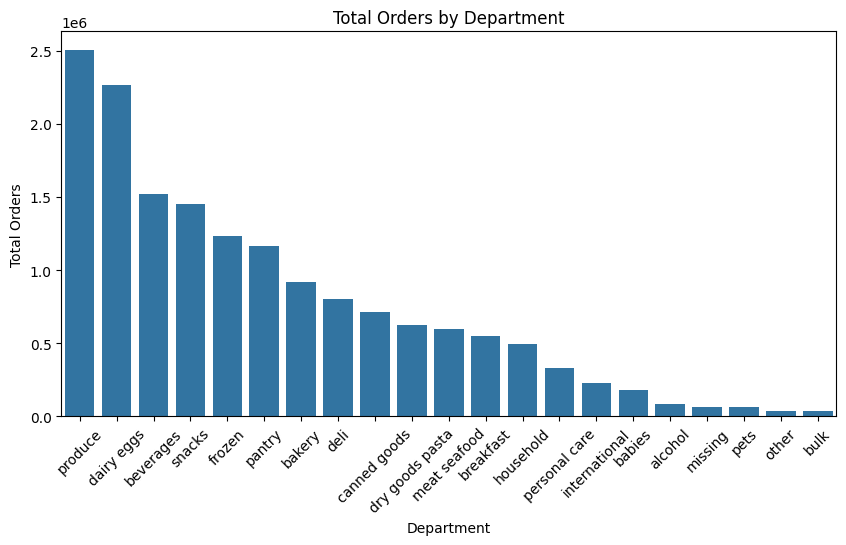

In [ ]:
# Total Orders by Department
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=result, x="department", y="total_orders")

plt.xlabel("Department")
plt.ylabel("Total Orders")
plt.title("Total Orders by Department")

plt.xticks(rotation=45) 
plt.show()


### 8. Summary

This notebook was used to validate data quality, confirm transformation logic, test analytical queries, and support the design of the final dashboard.